In [ ]:
from pathlib import Path
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import polars.selectors as cs
import json
pl.Config.set_tbl_cols(-1)

# A note on selectors:
# Selectors allow for more intuitive selection of columns from DataFrame or LazyFrame objects based on their name, dtype or other properties. They unify and build on the related functionality that is available through the col() expression and can also broadcast expressions over the selected columns.

polars.config.Config

In [ ]:
train_df = pl.read_csv("train.csv", null_values=["NA"])

In [55]:
train_df.head()

Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
i64,i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,i64,i64,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64
1,60,"""RL""",65,8450,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2003,2003,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",196,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""No""","""GLQ""",706,"""Unf""",0,150,856,"""GasA""","""Ex""","""Y""","""SBrkr""",856,854,0,1710,1,0,2,1,3,1,"""Gd""",8,"""Typ""",0,null,"""Attchd""",2003,"""RFn""",2,548,"""TA""","""TA""","""Y""",0,61,0,0,0,0,null,null,null,0,2,2008,"""WD""","""Normal""",208500
2,20,"""RL""",80,9600,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""FR2""","""Gtl""","""Veenker""","""Feedr""","""Norm""","""1Fam""","""1Story""",6,8,1976,1976,"""Gable""","""CompShg""","""MetalSd""","""MetalSd""","""None""",0,"""TA""","""TA""","""CBlock""","""Gd""","""TA""","""Gd""","""ALQ""",978,"""Unf""",0,284,1262,"""GasA""","""Ex""","""Y""","""SBrkr""",1262,0,0,1262,0,1,2,0,3,1,"""TA""",6,"""Typ""",1,"""TA""","""Attchd""",1976,"""RFn""",2,460,"""TA""","""TA""","""Y""",298,0,0,0,0,0,null,null,null,0,5,2007,"""WD""","""Normal""",181500
3,60,"""RL""",68,11250,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2001,2002,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",162,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""Mn""","""GLQ""",486,"""Unf""",0,434,920,"""GasA""","""Ex""","""Y""","""SBrkr""",920,866,0,1786,1,0,2,1,3,1,"""Gd""",6,"""Typ""",1,"""TA""","""Attchd""",2001,"""RFn""",2,608,"""TA""","""TA""","""Y""",0,42,0,0,0,0,null,null,null,0,9,2008,"""WD""","""Normal""",223500
4,70,"""RL""",60,9550,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""Crawfor""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,1915,1970,"""Gable""","""CompShg""","""Wd Sdng""","""Wd Shng""","""None""",0,"""TA""","""TA""","""BrkTil""","""TA""","""Gd""","""No""","""ALQ""",216,"""Unf""",0,540,756,"""GasA""","""Gd""","""Y""","""SBrkr""",961,756,0,1717,1,0,1,0,3,1,"""Gd""",7,"""Typ""",1,"""Gd""","""Detchd""",1998,"""Unf""",3,642,"""TA""","""TA""","""Y""",0,35,272,0,0,0,null,null,null,0,2,2006,"""WD""","""Abnorml""",140000
5,60,"""RL""",84,14260,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""FR2""","""Gtl""","""NoRidge""","""Norm""","""Norm""","""1Fam""","""2Story""",8,5,2000,2000,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",350,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""Av""","""GLQ""",655,"""Unf""",0,490,1145,"""GasA""","""Ex""","""Y""","""SBrkr""",1145,1053,0,2198,1,0,2,1,4,1,"""Gd""",9,"""Typ""",1,"""TA""","""Attchd""",2000,"""RFn""",3,836,"""TA""","""TA""","""Y""",192,84,0,0,0,0,null,null,null,0,12,2008,"""WD""","""Normal""",250000


### Things to explore 
1. Missing Values
2. All the Numerical Variables
3. Distribution of the Numerical Vars
4. Categorical Vars
5. Cardinality of Categorical Vars
6. Outliers
7. Relationship between independent and dependent vars (sale price)


## Missing Values

In [ ]:
# Find all columns with NA/Null values
cols_with_na = []
for col in train_df.columns:
	if train_df[col].is_null().any():
		cols_with_na.append(col)
		print(f"{col}: {round(train_df[col].is_null().mean(), 3)*100}%")

LotFrontage: 17.7%
- description: Linear feet of street connected to property


Alley: 93.8%
- description: Type of alley access to property
- categories: {'Grvl': 'Gravel', 'Pave': 'Paved', 'NA': 'No alley access'}


MasVnrType: 0.5%
- description: Masonry veneer type
- categories: {'BrkCmn': 'Brick Common', 'BrkFace': 'Brick Face', 'CBlock': 'Cinder Block', 'None': 'None', 'Stone': 'Stone'}


MasVnrArea: 0.5%
- description: Masonry veneer area in square feet


BsmtQual: 2.5%
- description: Evaluates the height of the basement
- categories: {'Ex': 'Excellent (100+ inches)', 'Gd': 'Good (90-99 inches)', 'TA': 'Typical (80-89 inches)', 'Fa': 'Fair (70-79 inches)', 'Po': 'Poor (<70 inches', 'NA': 'No Basement'}


BsmtCond: 2.5%
- description: Evaluates the general condition of the basement
- categories: {'Ex': 'Excellent', 'Gd': 'Good', 'TA': 'Typical - slight dampness allowed', 'Fa': 'Fair - dampness or some cracking or settling', 'Po': 'Poor - Severe cracking, settling, or wetness', 'N

### Do these null values impact the avg. sales price? If so, how? 

LotFrontage: 17.7%
- description: Linear feet of street connected to property
shape: (2, 2)
┌─────────────┬───────────┐
│ LotFrontage ┆ SalePrice │
│ ---         ┆ ---       │
│ i32         ┆ f64       │
╞═════════════╪═══════════╡
│ 0           ┆ 159500.0  │
│ 1           ┆ 172400.0  │
└─────────────┴───────────┘


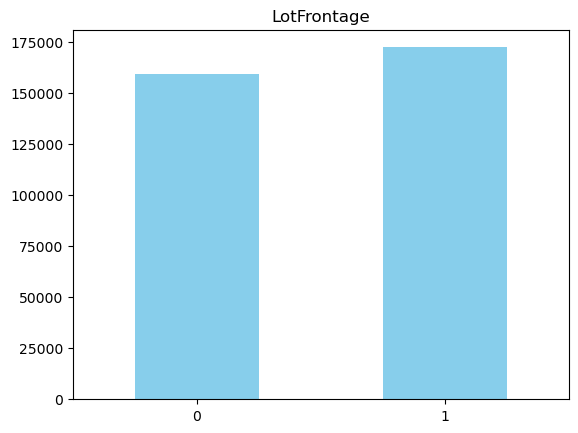

Alley: 93.8%
- description: Type of alley access to property
- categories: {'Grvl': 'Gravel', 'Pave': 'Paved', 'NA': 'No alley access'}
shape: (2, 2)
┌───────┬───────────┐
│ Alley ┆ SalePrice │
│ ---   ┆ ---       │
│ i32   ┆ f64       │
╞═══════╪═══════════╡
│ 0     ┆ 140000.0  │
│ 1     ┆ 165000.0  │
└───────┴───────────┘


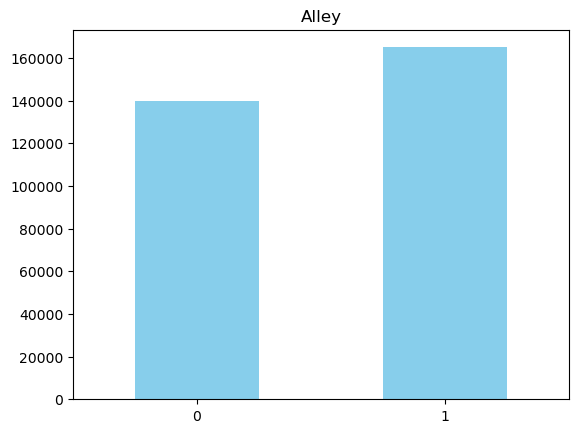

MasVnrType: 0.5%
- description: Masonry veneer type
- categories: {'BrkCmn': 'Brick Common', 'BrkFace': 'Brick Face', 'CBlock': 'Cinder Block', 'None': 'None', 'Stone': 'Stone'}
shape: (2, 2)
┌────────────┬───────────┐
│ MasVnrType ┆ SalePrice │
│ ---        ┆ ---       │
│ i32        ┆ f64       │
╞════════════╪═══════════╡
│ 0          ┆ 162700.0  │
│ 1          ┆ 203287.0  │
└────────────┴───────────┘


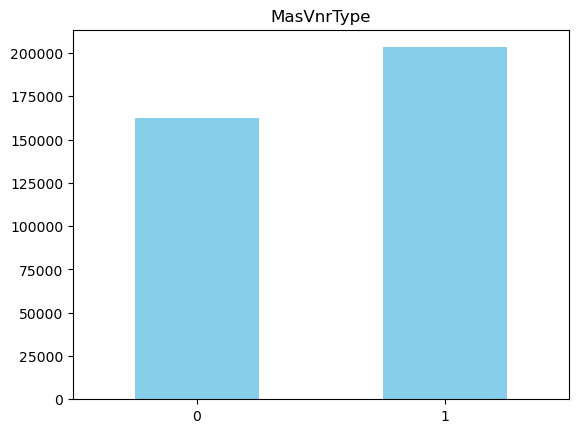

MasVnrArea: 0.5%
- description: Masonry veneer area in square feet
shape: (2, 2)
┌────────────┬───────────┐
│ MasVnrArea ┆ SalePrice │
│ ---        ┆ ---       │
│ i32        ┆ f64       │
╞════════════╪═══════════╡
│ 0          ┆ 162700.0  │
│ 1          ┆ 203287.0  │
└────────────┴───────────┘


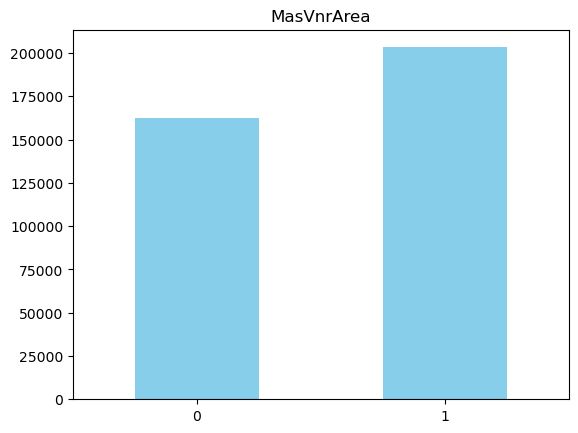

BsmtQual: 2.5%
- description: Evaluates the height of the basement
- categories: {'Ex': 'Excellent (100+ inches)', 'Gd': 'Good (90-99 inches)', 'TA': 'Typical (80-89 inches)', 'Fa': 'Fair (70-79 inches)', 'Po': 'Poor (<70 inches', 'NA': 'No Basement'}
shape: (2, 2)
┌──────────┬───────────┐
│ BsmtQual ┆ SalePrice │
│ ---      ┆ ---       │
│ i32      ┆ f64       │
╞══════════╪═══════════╡
│ 0        ┆ 165000.0  │
│ 1        ┆ 101800.0  │
└──────────┴───────────┘


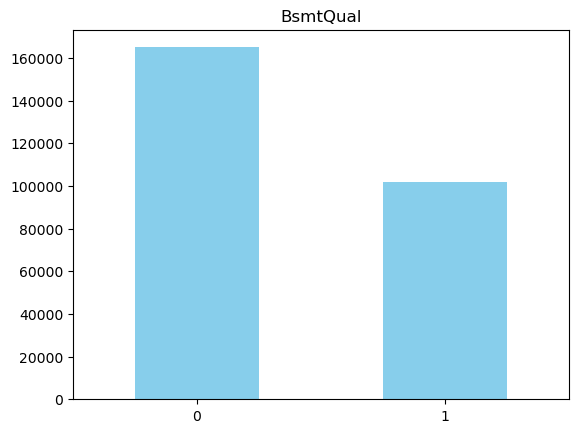

BsmtCond: 2.5%
- description: Evaluates the general condition of the basement
- categories: {'Ex': 'Excellent', 'Gd': 'Good', 'TA': 'Typical - slight dampness allowed', 'Fa': 'Fair - dampness or some cracking or settling', 'Po': 'Poor - Severe cracking, settling, or wetness', 'NA': 'No Basement'}
shape: (2, 2)
┌──────────┬───────────┐
│ BsmtCond ┆ SalePrice │
│ ---      ┆ ---       │
│ i32      ┆ f64       │
╞══════════╪═══════════╡
│ 0        ┆ 165000.0  │
│ 1        ┆ 101800.0  │
└──────────┴───────────┘


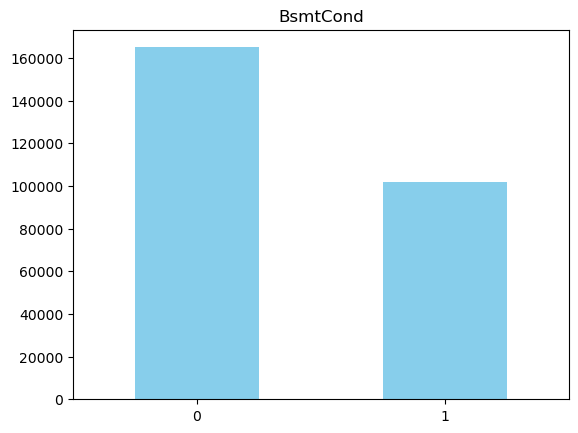

BsmtExposure: 2.6%
- description: Refers to walkout or garden level walls
- categories: {'Gd': 'Good Exposure', 'Av': 'Average Exposure (split levels or foyers typically score average or above)', 'Mn': 'Mimimum Exposure', 'No': 'No Exposure', 'NA': 'No Basement'}
shape: (2, 2)
┌──────────────┬───────────┐
│ BsmtExposure ┆ SalePrice │
│ ---          ┆ ---       │
│ i32          ┆ f64       │
╞══════════════╪═══════════╡
│ 0            ┆ 165000.0  │
│ 1            ┆ 104025.0  │
└──────────────┴───────────┘


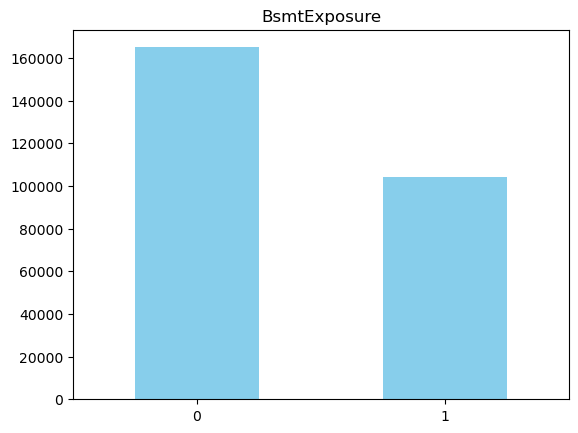

BsmtFinType1: 2.5%
- description: Rating of basement finished area
- categories: {'GLQ': 'Good Living Quarters', 'ALQ': 'Average Living Quarters', 'BLQ': 'Below Average Living Quarters', 'Rec': 'Average Rec Room', 'LwQ': 'Low Quality', 'Unf': 'Unfinshed', 'NA': 'No Basement'}
shape: (2, 2)
┌──────────────┬───────────┐
│ BsmtFinType1 ┆ SalePrice │
│ ---          ┆ ---       │
│ i32          ┆ f64       │
╞══════════════╪═══════════╡
│ 0            ┆ 165000.0  │
│ 1            ┆ 101800.0  │
└──────────────┴───────────┘


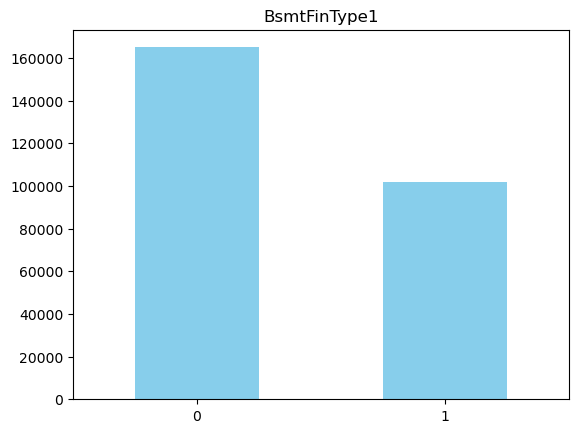

BsmtFinType2: 2.6%
- description: Rating of basement finished area (if multiple types)
- categories: {'GLQ': 'Good Living Quarters', 'ALQ': 'Average Living Quarters', 'BLQ': 'Below Average Living Quarters', 'Rec': 'Average Rec Room', 'LwQ': 'Low Quality', 'Unf': 'Unfinshed', 'NA': 'No Basement'}
shape: (2, 2)
┌──────────────┬───────────┐
│ BsmtFinType2 ┆ SalePrice │
│ ---          ┆ ---       │
│ i32          ┆ f64       │
╞══════════════╪═══════════╡
│ 0            ┆ 165000.0  │
│ 1            ┆ 104025.0  │
└──────────────┴───────────┘


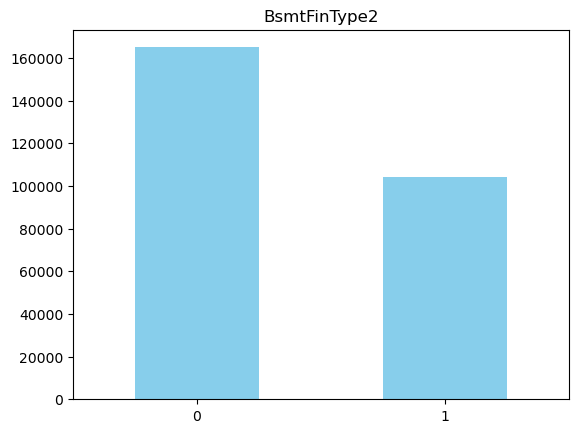

Electrical: 0.1%
- description: Electrical system
- categories: {'SBrkr': 'Standard Circuit Breakers & Romex', 'FuseA': 'Fuse Box over 60 AMP and all Romex wiring (Average)', 'FuseF': '60 AMP Fuse Box and mostly Romex wiring (Fair)', 'FuseP': '60 AMP Fuse Box and mostly knob & tube wiring (poor)', 'Mix': 'Mixed'}
shape: (2, 2)
┌────────────┬───────────┐
│ Electrical ┆ SalePrice │
│ ---        ┆ ---       │
│ i32        ┆ f64       │
╞════════════╪═══════════╡
│ 0          ┆ 163000.0  │
│ 1          ┆ 167500.0  │
└────────────┴───────────┘


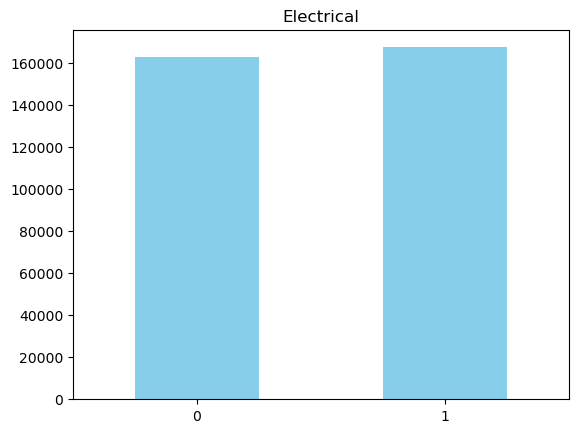

FireplaceQu: 47.3%
- description: Fireplace quality
- categories: {'Ex': 'Excellent - Exceptional Masonry Fireplace', 'Gd': 'Good - Masonry Fireplace in main level', 'TA': 'Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement', 'Fa': 'Fair - Prefabricated Fireplace in basement', 'Po': 'Poor - Ben Franklin Stove', 'NA': 'No Fireplace'}
shape: (2, 2)
┌─────────────┬───────────┐
│ FireplaceQu ┆ SalePrice │
│ ---         ┆ ---       │
│ i32         ┆ f64       │
╞═════════════╪═══════════╡
│ 0           ┆ 191000.0  │
│ 1           ┆ 135000.0  │
└─────────────┴───────────┘


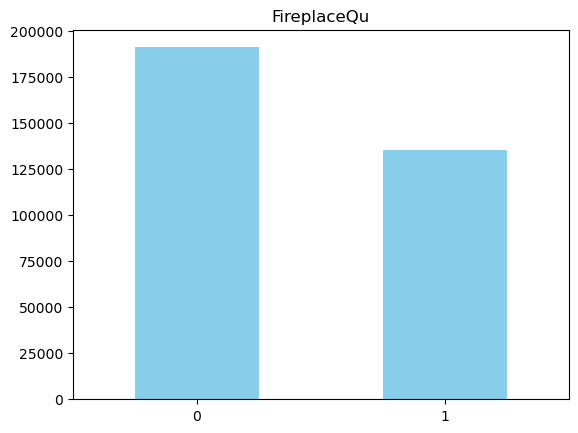

GarageType: 5.5%
- description: Garage location
- categories: {'2Types': 'More than one type of garage', 'Attchd': 'Attached to home', 'Basment': 'Basement Garage', 'BuiltIn': 'Built-In (Garage part of house - typically has room above garage)', 'CarPort': 'Car Port', 'Detchd': 'Detached from home', 'NA': 'No Garage'}
shape: (2, 2)
┌────────────┬───────────┐
│ GarageType ┆ SalePrice │
│ ---        ┆ ---       │
│ i32        ┆ f64       │
╞════════════╪═══════════╡
│ 0          ┆ 167500.0  │
│ 1          ┆ 100000.0  │
└────────────┴───────────┘


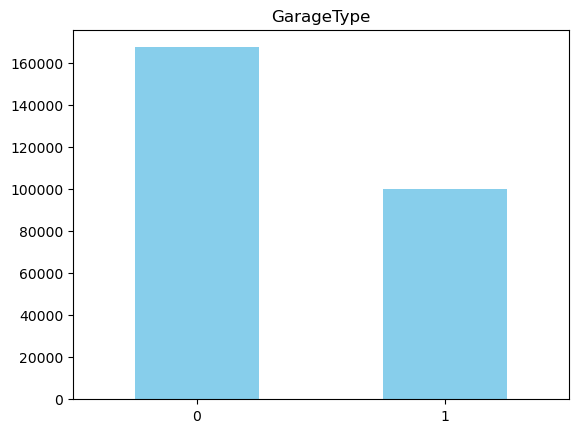

GarageYrBlt: 5.5%
- description: Year garage was built
shape: (2, 2)
┌─────────────┬───────────┐
│ GarageYrBlt ┆ SalePrice │
│ ---         ┆ ---       │
│ i32         ┆ f64       │
╞═════════════╪═══════════╡
│ 0           ┆ 167500.0  │
│ 1           ┆ 100000.0  │
└─────────────┴───────────┘


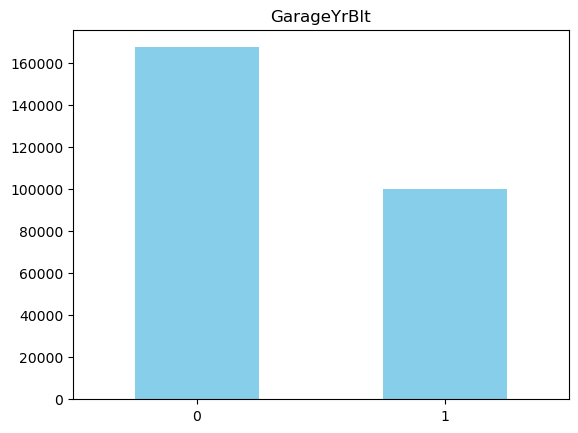

GarageFinish: 5.5%
- description: Interior finish of the garage
- categories: {'Fin': 'Finished', 'RFn': 'Rough Finished', 'Unf': 'Unfinished', 'NA': 'No Garage'}
shape: (2, 2)
┌──────────────┬───────────┐
│ GarageFinish ┆ SalePrice │
│ ---          ┆ ---       │
│ i32          ┆ f64       │
╞══════════════╪═══════════╡
│ 0            ┆ 167500.0  │
│ 1            ┆ 100000.0  │
└──────────────┴───────────┘


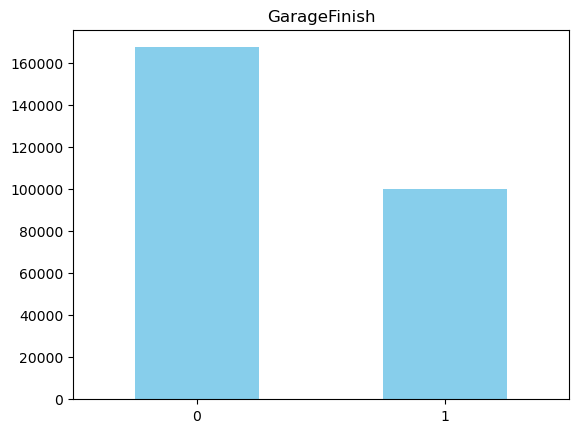

GarageQual: 5.5%
- description: Garage quality
- categories: {'Ex': 'Excellent', 'Gd': 'Good', 'TA': 'Typical/Average', 'Fa': 'Fair', 'Po': 'Poor', 'NA': 'No Garage'}
shape: (2, 2)
┌────────────┬───────────┐
│ GarageQual ┆ SalePrice │
│ ---        ┆ ---       │
│ i32        ┆ f64       │
╞════════════╪═══════════╡
│ 0          ┆ 167500.0  │
│ 1          ┆ 100000.0  │
└────────────┴───────────┘


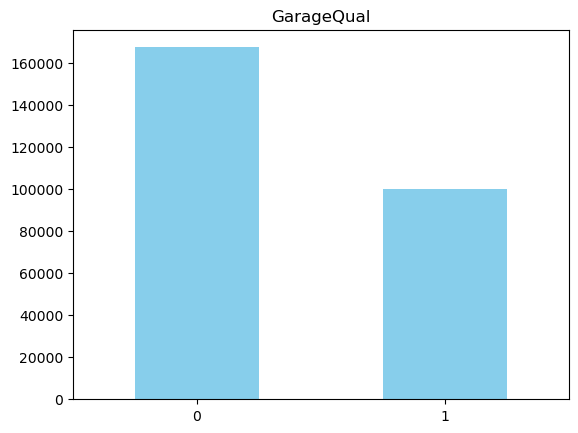

GarageCond: 5.5%
- description: Garage condition
- categories: {'Ex': 'Excellent', 'Gd': 'Good', 'TA': 'Typical/Average', 'Fa': 'Fair', 'Po': 'Poor', 'NA': 'No Garage'}
shape: (2, 2)
┌────────────┬───────────┐
│ GarageCond ┆ SalePrice │
│ ---        ┆ ---       │
│ i32        ┆ f64       │
╞════════════╪═══════════╡
│ 0          ┆ 167500.0  │
│ 1          ┆ 100000.0  │
└────────────┴───────────┘


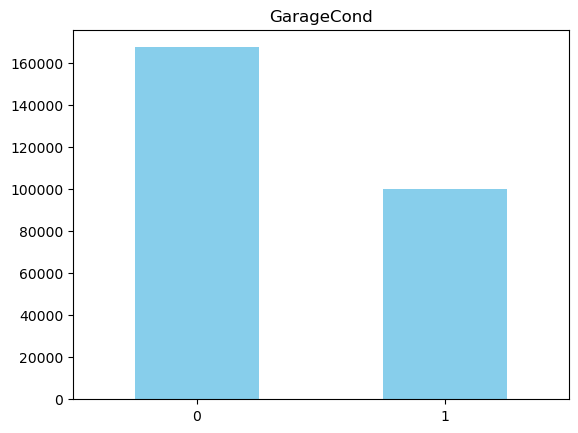

PoolQC: 99.5%
- description: Pool quality
- categories: {'Ex': 'Excellent', 'Gd': 'Good', 'TA': 'Average/Typical', 'Fa': 'Fair', 'NA': 'No Pool'}
shape: (2, 2)
┌────────┬───────────┐
│ PoolQC ┆ SalePrice │
│ ---    ┆ ---       │
│ i32    ┆ f64       │
╞════════╪═══════════╡
│ 0      ┆ 235000.0  │
│ 1      ┆ 162900.0  │
└────────┴───────────┘


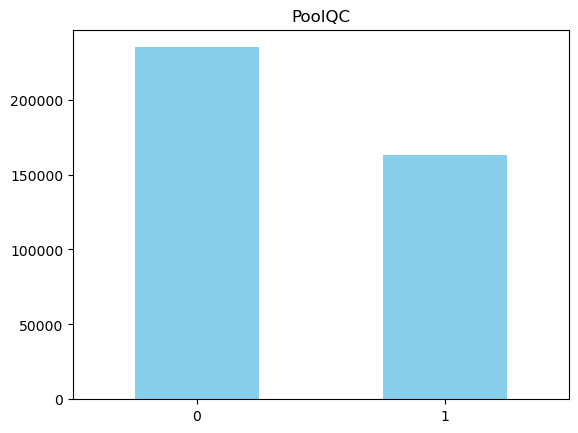

Fence: 80.80000000000001%
- description: Fence quality
- categories: {'GdPrv': 'Good Privacy', 'MnPrv': 'Minimum Privacy', 'GdWo': 'Good Wood', 'MnWw': 'Minimum Wood/Wire', 'NA': 'No Fence'}
shape: (2, 2)
┌───────┬───────────┐
│ Fence ┆ SalePrice │
│ ---   ┆ ---       │
│ i32   ┆ f64       │
╞═══════╪═══════════╡
│ 0     ┆ 141500.0  │
│ 1     ┆ 173000.0  │
└───────┴───────────┘


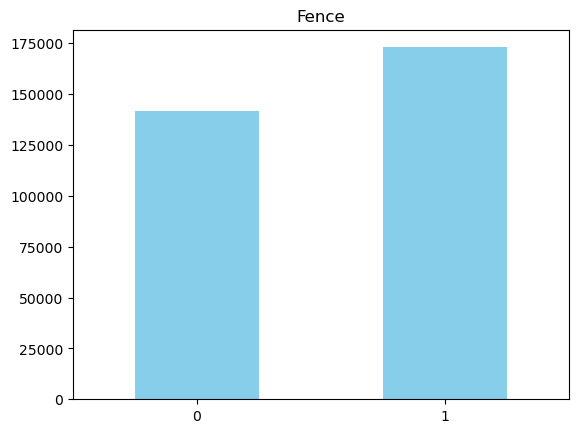

MiscFeature: 96.3%
- description: Miscellaneous feature not covered in other categories
- categories: {'Elev': 'Elevator', 'Gar2': '2nd Garage (if not described in garage section)', 'Othr': 'Other', 'Shed': 'Shed (over 100 SF)', 'TenC': 'Tennis Court', 'NA': 'None'}
shape: (2, 2)
┌─────────────┬───────────┐
│ MiscFeature ┆ SalePrice │
│ ---         ┆ ---       │
│ i32         ┆ f64       │
╞═════════════╪═══════════╡
│ 0           ┆ 146000.0  │
│ 1           ┆ 164250.0  │
└─────────────┴───────────┘


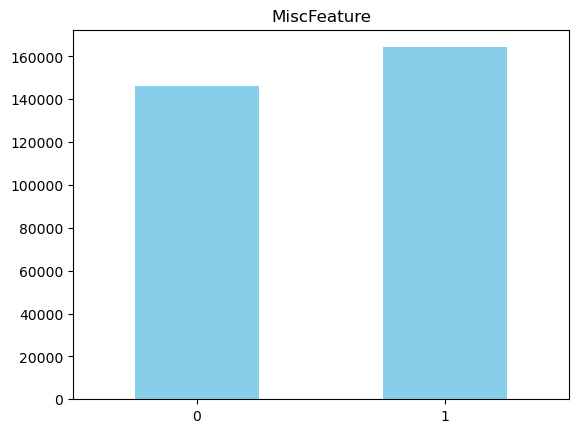

In [69]:
with open("data_description.json", "r") as f:
	data_desc = json.load(f)
for col in cols_with_na:
    train_df_copy = train_df.clone()
    print(f"{col}: {round(train_df_copy[col].is_null().mean(), 3)*100}%")

    for key, val in data_desc[col].items():
        print(f"- {key}: {val}")
    train_df_copy = train_df_copy.with_columns(
        pl.when(pl.col(col).is_null())
        .then(1)
        .otherwise(0)
        .alias(col))
    print(train_df_copy.group_by(col).agg(pl.col("SalePrice").median()))
    train_df_copy.group_by(col).agg(pl.col("SalePrice").median()).to_pandas().plot.bar(y="SalePrice", legend=False, color="skyblue", rot=0)
    plt.title(col)
    plt.show()	

**There are two types of null values:**
1. Implies a value for the variable is missing. For some features like `LotFrontage`, a missing value just means that the measurement is missing.
2. Implies the entity (like basement, alley) represented by the feature does not exist for a given property. For example, a null or NA value  for `BsmtFinType1`  means that basement does not exist. Similarly, for `AlleyAccess` a NA value just means the property does not have alley access.  

**Through the above plots, we see the following types of relationships:**
1. Increase in SalePrice when values for the feature are missing. 
2. Increase/decrease in SalePrice when entity (like basement, alley) represented by the feature doesn't exist. 

These considerations will be important in how we handle missing values in the feature selection stage. 

## Numerical Values

In [75]:
train_df_copy = train_df.clone()
# Select all numerical columns
num_train_df = train_df_copy.select(cs.by_dtype(pl.Int64, pl.Float64))

numerical_vars = num_train_df.columns
num_train_df.head()


Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
1,60,65,8450,7,5,2003,2003,196,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003,2,548,0,61,0,0,0,0,0,2,2008,208500
2,20,80,9600,6,8,1976,1976,0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976,2,460,298,0,0,0,0,0,0,5,2007,181500
3,60,68,11250,7,5,2001,2002,162,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001,2,608,0,42,0,0,0,0,0,9,2008,223500
4,70,60,9550,7,5,1915,1970,0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998,3,642,0,35,272,0,0,0,0,2,2006,140000
5,60,84,14260,8,5,2000,2000,350,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000,3,836,192,84,0,0,0,0,0,12,2008,250000


In [73]:
print(f"There are {num_train_df.shape[1]} numerical variables in the dataset.")

There are 38 numerical variables in the dataset.


#### Temporal features
We want to separate and handle temporal variables such as `YearBuilt`. 

In [77]:
year_vars = [feat for feat in numerical_vars if "Yr" in feat or "Year" in feat]
year_vars

['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']

In [79]:
# Unique year values across the 4 variables
for year_var in year_vars:
	print(f"{year_var} - {list(train_df_copy[year_var].unique())}\n")

YearBuilt - [1872, 1875, 1880, 1882, 1885, 1890, 1892, 1893, 1898, 1900, 1904, 1905, 1906, 1908, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010]

YearRemodAdd - [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999

Text(0.5, 1.0, 'House Price vs Year Sold')

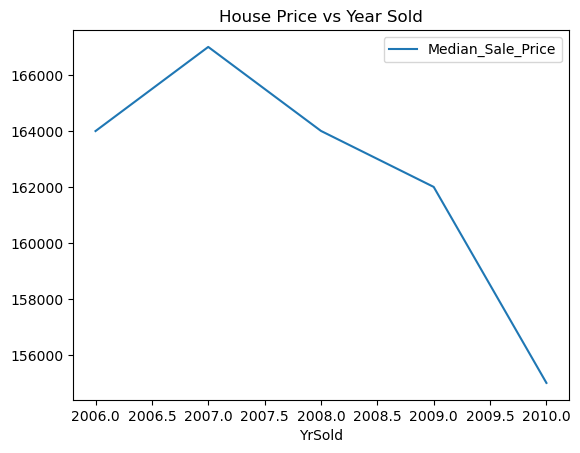

In [93]:
# What is the relationship between `YrSold` and `SalePrice`? 
sale_price_by_year = train_df_copy.group_by("YrSold").agg(pl.col("SalePrice").median().alias("Median_Sale_Price")).sort(by="YrSold")

sale_price_by_year.to_pandas().plot(x="YrSold", y="Median_Sale_Price", kind="line")
plt.title("House Price vs Year Sold")


The expected trend is that `SalePrice` would increase as time goes on unless there are other factors such age of the house etc influencing the price.